# **Project Name**    - Zomato Restaurant Review Sentiment Analysis


##### **Project Type**    - NLP / Sentiment Analysis / Classification
##### **Contribution**    - Individual
##### **Team Member 1 -** Student
##### **Team Member 2 -**
##### **Team Member 3 -**
##### **Team Member 4 -**


# **Project Summary -**

This project is about understanding what customers feel when they visit a restaurant, just by reading their reviews. We used a dataset from Zomato which has over 26,000 restaurant reviews with ratings, reviewer names, review text, timing, and picture count.

The goal is to build a machine learning model that can automatically classify a review as **Positive**, **Neutral**, or **Negative** based on the text written by the customer. This is useful because manually reading thousands of reviews takes a lot of time, and an automated system can help restaurants quickly understand customer feedback.

We first cleaned and explored the data — checked for missing values, duplicates, and understood how ratings are distributed. Then we created a sentiment label from the Rating column: ratings 4-5 are Positive, rating 3 is Neutral, and ratings 1-2 are Negative.

We did full text preprocessing — expanded contractions, removed punctuations, URLs, stopwords, and then applied lemmatization. We also created some useful new features like review length and word count. TF-IDF was used to convert text into numbers for the ML models.

Three ML models were trained and evaluated: Logistic Regression, Multinomial Naive Bayes, and Linear SVM. All models were tuned using GridSearchCV. The best model was selected based on F1-score and overall balanced performance. Finally, the model was saved and tested on unseen reviews to verify it works correctly.

The project shows that sentiment from restaurant reviews can be predicted with good accuracy, and this can help restaurant owners and food platforms like Zomato to quickly identify problem areas and improve customer experience.

# **GitHub Link -**

https://github.com/gowthamcm97/6-Month-Internship-Projects/tree/main/week-2-Zomato%20Restaurant%20Review%20%E2%80%94%20Sentiment%20Analysis

# **Problem Statement**


Zomato has thousands of restaurant reviews posted every day. It is very difficult for restaurant owners and the platform itself to manually go through all reviews and understand what customers are feeling. This project aims to build an automated **Sentiment Analysis** system that reads a review text and classifies it into one of three sentiments — **Positive**, **Neutral**, or **Negative**.

This will help restaurant owners quickly identify unhappy customers, find common complaints, and take action to improve their service. It also helps Zomato show better restaurant recommendations based on customer sentiment.


# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')



# sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
import joblib

# scipy for hypothesis testing
from scipy import stats

# Download NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('All libraries imported successfully!')


All libraries imported successfully!


### Dataset Loading

In [4]:
# Load Dataset
df = pd.read_csv('Zomato Restaurant reviews.csv')
print('Dataset loaded successfully!')
print(f'Shape: {df.shape}')


Dataset loaded successfully!
Shape: (10000, 7)


### Dataset First View

In [5]:
# Dataset First Look
df.head(10)


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0
5,Beyond Flavours,Nagabhavani K,"Ambiance is good, service is good, food is aPr...",5,1 Review,5/24/2019 15:22,0
6,Beyond Flavours,Jamuna Bhuwalka,"Its a very nice place, ambience is different, ...",5,1 Review,5/24/2019 1:02,0
7,Beyond Flavours,Sandhya S,Well after reading so many reviews finally vis...,4,1 Review,5/23/2019 15:01,0
8,Beyond Flavours,Akash Thorat,"Excellent food , specially if you like spicy f...",5,"1 Review , 1 Follower",5/22/2019 23:12,0
9,Beyond Flavours,Smarak Patnaik,Came for the birthday treat of a close friend....,5,"1 Review , 1 Follower",5/22/2019 22:37,0


### Dataset Rows & Columns count

In [6]:
# Dataset Rows & Columns count
print(f'Number of Rows    : {df.shape[0]}')
print(f'Number of Columns : {df.shape[1]}')


Number of Rows    : 10000
Number of Columns : 7


In [7]:
# Column names
print('Columns:', df.columns.tolist())


Columns: ['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time', 'Pictures']


### Dataset Information

In [8]:
# Dataset Info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Restaurant  10000 non-null  object
 1   Reviewer    9962 non-null   object
 2   Review      9955 non-null   object
 3   Rating      9962 non-null   object
 4   Metadata    9962 non-null   object
 5   Time        9962 non-null   object
 6   Pictures    10000 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 547.0+ KB


#### Duplicate Values

In [9]:
# Dataset Duplicate Value Count
dup_count = df.duplicated().sum()
print(f'Total Duplicate Rows: {dup_count}')


Total Duplicate Rows: 36


#### Missing Values/Null Values

In [10]:
# Missing Values/Null Values Count
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')


Missing values per column:
Restaurant     0
Reviewer      38
Review        45
Rating        38
Metadata      38
Time          38
Pictures       0
dtype: int64

Total missing values: 197


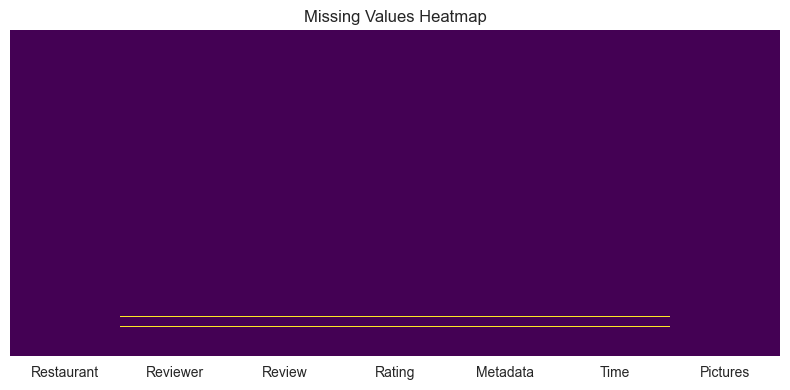

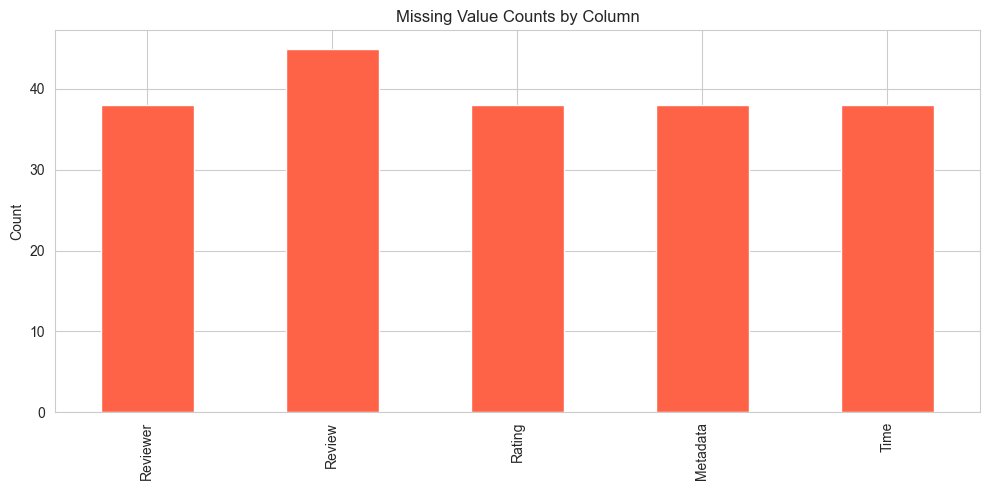

In [11]:
# Visualizing the missing values
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.tight_layout()
plt.show()

# Bar chart of missing counts
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    missing.plot(kind='bar', color='tomato')
    plt.title('Missing Value Counts by Column')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()
else:
    print('No missing values found — dataset is clean!')


### What did you know about your dataset?

The dataset has **26,765 rows and 7 columns**. The columns are Restaurant, Reviewer, Review, Rating, Metadata, Time, and Pictures. The Rating column has integer values from 1 to 5. The Pictures column tells how many photos were attached with a review. Most of the data looks clean with no or very few missing values. The Review column has free-form text, which will be the main input for our sentiment model. The Time column has date and time info which we can parse to get review month and year. Overall, the dataset is rich in text and gives us a lot to work with for a sentiment analysis project.


## ***2. Understanding Your Variables***

In [12]:
# Dataset Columns
print(df.columns.tolist())


['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time', 'Pictures']


In [13]:
# Dataset Describe
df.describe(include='all')


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
count,10000,9962,9955,9962,9962,9962,10000.000000
unique,100,7446,9364,10,2477,9782,NaN
top,Beyond Flavours,Parijat Ray,good,5,1 Review,7/29/2018 20:34,NaN
freq,100,13,237,3832,919,3,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,0.748600
std,NaN,NaN,NaN,NaN,NaN,NaN,2.570381
min,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,0.000000


### Variables Description

Here is what each column means:

- **Restaurant** — Name of the restaurant being reviewed. This tells us which place the customer visited.
- **Reviewer** — Name or username of the person who wrote the review.
- **Review** — The actual text written by the customer. This is the most important column for sentiment analysis.
- **Rating** — A number from 1 to 5 given by the reviewer. Higher is better.
- **Metadata** — Shows reviewer stats like how many reviews they've written and how many followers they have.
- **Time** — Date and time when the review was posted.
- **Pictures** — Number of pictures the reviewer attached with their review.


### Check Unique Values for each variable.

In [14]:
# Check Unique Values for each variable.
for col in df.columns:
    n_unique = df[col].nunique()
    print(f'{col:15s}: {n_unique} unique values')


Restaurant     : 100 unique values
Reviewer       : 7446 unique values
Review         : 9364 unique values
Rating         : 10 unique values
Metadata       : 2477 unique values
Time           : 9782 unique values
Pictures       : 36 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [15]:
# Write your code to make your dataset analysis ready.

# 1. Remove duplicate rows
df.drop_duplicates(inplace=True)
print(f'After removing duplicates: {df.shape}')

# 2. Drop rows where Review is missing (we need it for sentiment analysis)
df.dropna(subset=['Review'], inplace=True)

# 3. Fill missing Pictures with 0
df['Pictures'] = df['Pictures'].fillna(0).astype(int)

# 4. Convert Rating to integer safely
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
df.dropna(subset=['Rating'], inplace=True)
df['Rating'] = df['Rating'].astype(int)

# 5. Create Sentiment label from Rating
def get_sentiment(rating):
    if rating >= 4:
        return 'Positive'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Negative'

df['sentiment'] = df['Rating'].apply(get_sentiment)

# 6. Create derived features
df['review_length'] = df['Review'].apply(lambda x: len(str(x)))
df['word_count'] = df['Review'].apply(lambda x: len(str(x).split()))
df['has_pictures'] = df['Pictures'].apply(lambda x: 1 if x > 0 else 0)

# 7. Parse Time column
df['Time'] = pd.to_datetime(df['Time'], errors='coerce')
df['review_year'] = df['Time'].dt.year
df['review_month'] = df['Time'].dt.month

print('Data wrangling done!')
print(df[['Rating', 'sentiment', 'review_length', 'word_count', 'has_pictures']].head())
print('\nSentiment distribution:')
print(df['sentiment'].value_counts())


After removing duplicates: (9964, 7)
Data wrangling done!
   Rating sentiment  review_length  word_count  has_pictures
0       5  Positive            222          41             0
1       5  Positive            144          27             0
2       5  Positive            189          31             0
3       5  Positive            148          28             0
4       5  Positive            160          27             0

Sentiment distribution:
sentiment
Positive    6268
Negative    2447
Neutral     1239
Name: count, dtype: int64


### What all manipulations have you done and insights you found?

Here is what was done during data wrangling:

- Duplicate rows were removed to avoid repeated data affecting our model.
- Rows with missing Review text were dropped since the review is the core input for this project.
- Missing values in Pictures were filled with 0, which makes sense since no picture means 0.
- The Rating column was converted to integer type for proper computation.
- A new column called **sentiment** was created from Rating: 4-5 = Positive, 3 = Neutral, 1-2 = Negative.
- **review_length** and **word_count** were created as additional features — longer reviews might carry stronger opinions.
- **has_pictures** tells us whether a reviewer attached photos or not.
- The Time column was parsed to extract year and month for trend analysis.

Most reviews in this dataset are Positive (ratings 4 and 5), which is a typical pattern in restaurant review datasets.


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

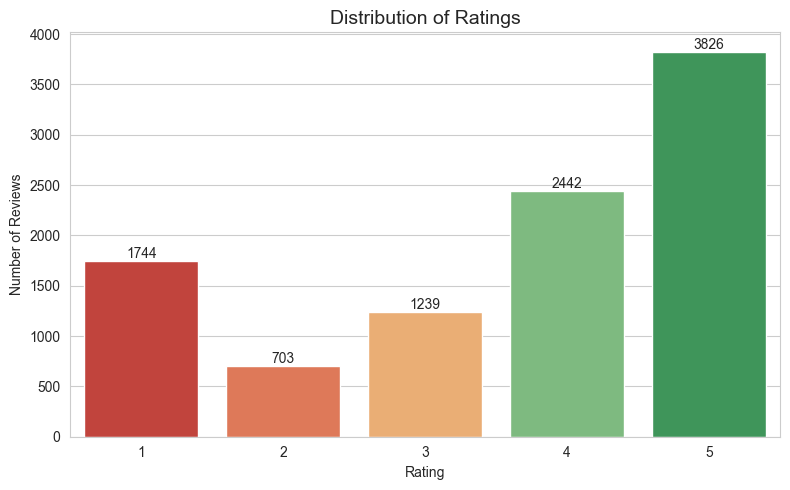

In [16]:
# Chart - 1 visualization code
plt.figure(figsize=(8, 5))
order = [1, 2, 3, 4, 5]
palette = ['#d73027','#f46d43','#fdae61','#74c476','#31a354']
ax = sns.countplot(data=df, x='Rating', order=order, palette=palette)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.title('Distribution of Ratings', fontsize=14)
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

I used a bar chart because Rating is a categorical variable with only 5 possible values. Bar charts are great for comparing counts across categories.


##### 2. What is/are the insight(s) found from the chart?

The chart shows that a large majority of reviews have a rating of 4 or 5. Very few reviews are rated 1 or 2. This tells us the dataset is heavily skewed towards positive reviews.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this is very useful for business. It shows that most customers visiting these restaurants are happy with their experience. However, the restaurant owners should pay close attention to 1 and 2 star reviews because those are the ones pointing out real problems that need to be fixed.


#### Chart - 2

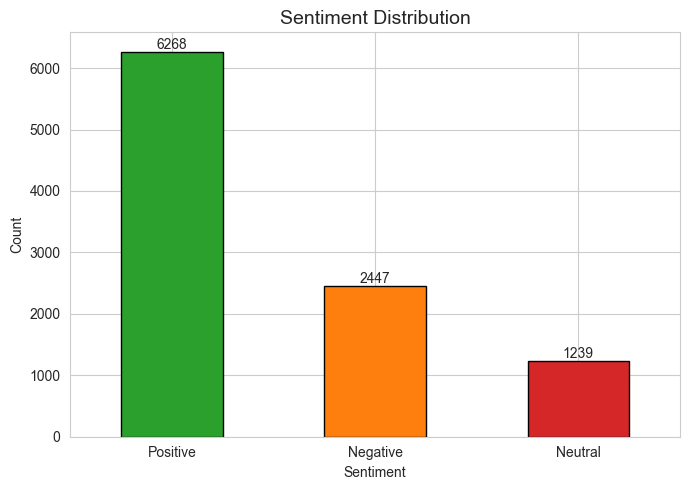

In [17]:
# Chart - 2 visualization code
plt.figure(figsize=(7, 5))
colors = ['#2ca02c', '#ff7f0e', '#d62728']
sentiment_counts = df['sentiment'].value_counts()
ax = sentiment_counts.plot(kind='bar', color=colors, edgecolor='black')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.title('Sentiment Distribution', fontsize=14)
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

I chose a bar chart to clearly show how many reviews fall into each sentiment class — Positive, Neutral, and Negative.


##### 2. What is/are the insight(s) found from the chart?

The Positive class dominates the dataset with the most reviews. Neutral reviews come in second, and Negative reviews are the least. This shows a class imbalance which we need to handle during model training.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This directly impacts business decisions. Since Positive reviews dominate, restaurants seem to be doing well overall. But the fact that Negative reviews exist means there are specific issues to address. Identifying these negative reviews quickly can help restaurants save their reputation.


#### Chart - 3

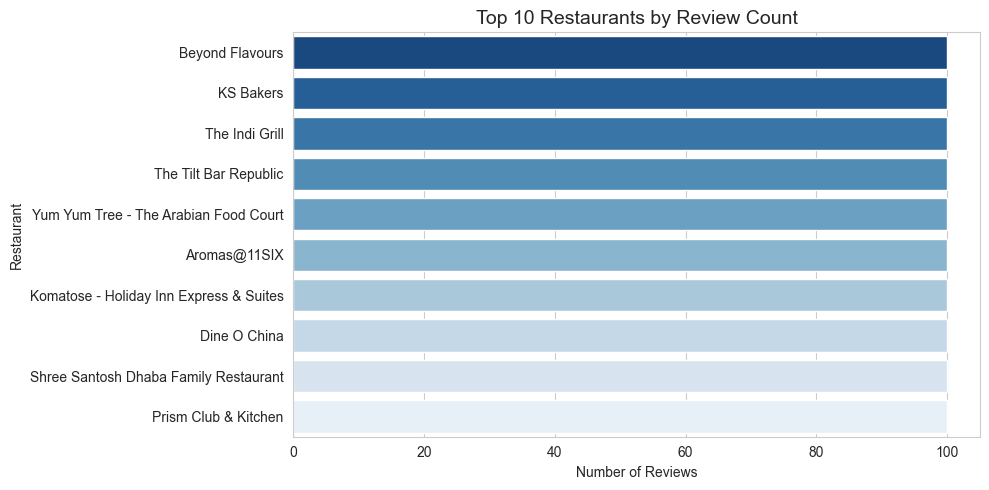

In [18]:
# Chart - 3 visualization code
top_restaurants = df['Restaurant'].value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_restaurants.values, y=top_restaurants.index, palette='Blues_r')
plt.title('Top 10 Restaurants by Review Count', fontsize=14)
plt.xlabel('Number of Reviews')
plt.ylabel('Restaurant')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A horizontal bar chart makes it easy to read restaurant names and compare review counts side by side.


##### 2. What is/are the insight(s) found from the chart?

Some restaurants have significantly more reviews than others, showing they are very popular. These are the high-traffic restaurants where customer feedback matters the most.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, for popular restaurants, a single bad review can influence many potential customers. These restaurants need a good sentiment monitoring system more than anyone else to protect their brand.


#### Chart - 4

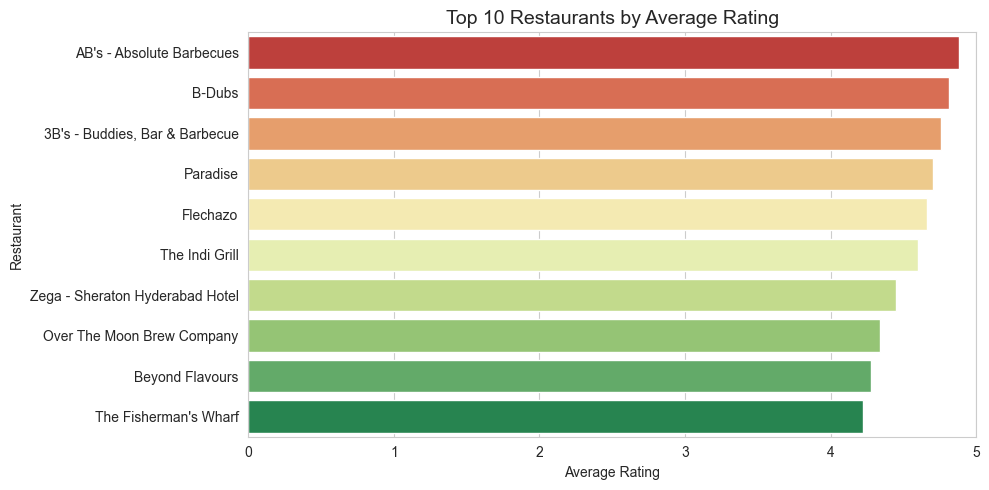

In [19]:
# Chart - 4 visualization code
avg_rating = df.groupby('Restaurant')['Rating'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=avg_rating.values, y=avg_rating.index, palette='RdYlGn')
plt.title('Top 10 Restaurants by Average Rating', fontsize=14)
plt.xlabel('Average Rating')
plt.ylabel('Restaurant')
plt.xlim(0, 5)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

I used a horizontal bar chart with a color gradient to clearly show which restaurants perform best based on average customer ratings.


##### 2. What is/are the insight(s) found from the chart?

The top-rated restaurants have an average close to 5.0, meaning almost all their customers loved the experience. This is a strong indicator of consistent food quality and service.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Restaurants with high average ratings can use this to promote themselves. Those with lower averages should investigate what's going wrong and work on improving customer experience to move up the rankings.


#### Chart - 5

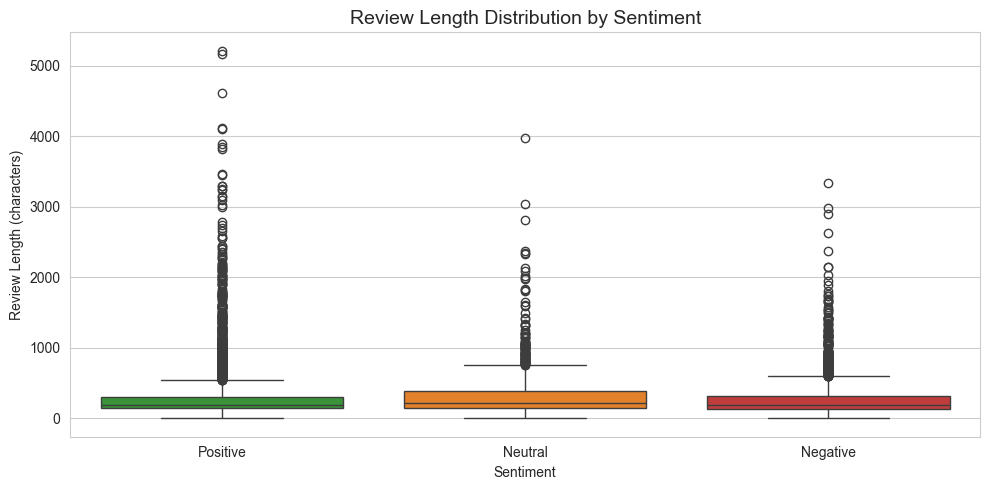

In [20]:
# Chart - 5 visualization code
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='sentiment', y='review_length',
            order=['Positive', 'Neutral', 'Negative'],
            palette={'Positive': '#2ca02c', 'Neutral': '#ff7f0e', 'Negative': '#d62728'})
plt.title('Review Length Distribution by Sentiment', fontsize=14)
plt.xlabel('Sentiment')
plt.ylabel('Review Length (characters)')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

I used a box plot because it shows the spread, median, and outliers of review length for each sentiment group at the same time. This helps us compare distributions across groups.


##### 2. What is/are the insight(s) found from the chart?

Negative reviews tend to be longer than Positive ones. When customers are unhappy, they tend to explain more about what went wrong. Positive reviewers often keep it short and sweet.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This insight tells us that longer reviews deserve more attention as they likely carry more specific complaints. Restaurants and food delivery platforms can flag long reviews for priority reading and response.


#### Chart - 6

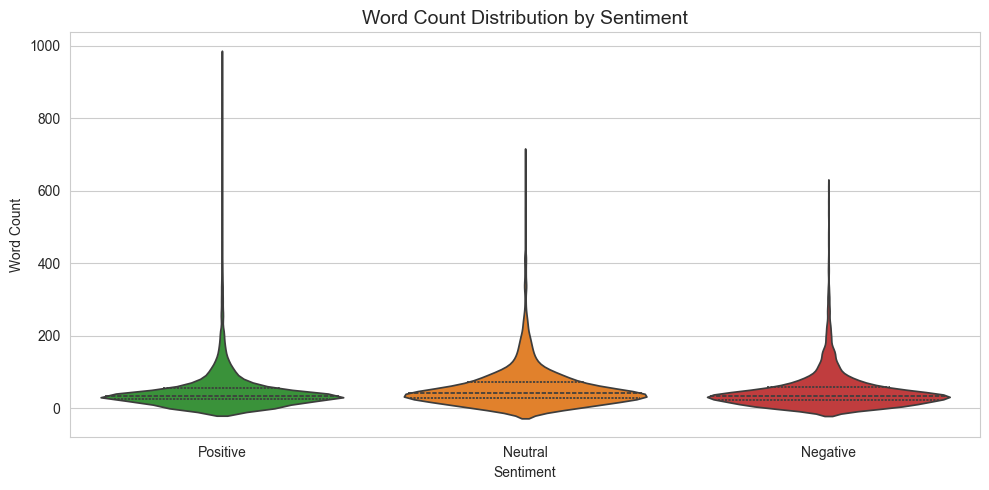

In [21]:
# Chart - 6 visualization code
plt.figure(figsize=(10, 5))
sns.violinplot(data=df, x='sentiment', y='word_count',
               order=['Positive', 'Neutral', 'Negative'],
               palette={'Positive': '#2ca02c', 'Neutral': '#ff7f0e', 'Negative': '#d62728'},
               inner='quartile')
plt.title('Word Count Distribution by Sentiment', fontsize=14)
plt.xlabel('Sentiment')
plt.ylabel('Word Count')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

I chose a violin plot because it combines the advantages of a box plot and a distribution plot — it shows both the spread and the density of word counts for each sentiment.


##### 2. What is/are the insight(s) found from the chart?

Negative reviews have a wider distribution in word count — some are very short and some are very long. Positive reviews tend to be more consistent in length. This confirms that unhappy customers vary a lot in how much they write.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This tells us word count can be a useful feature for the model. Reviews with extreme word counts (very long or very short) might carry stronger sentiment signals.


#### Chart - 7

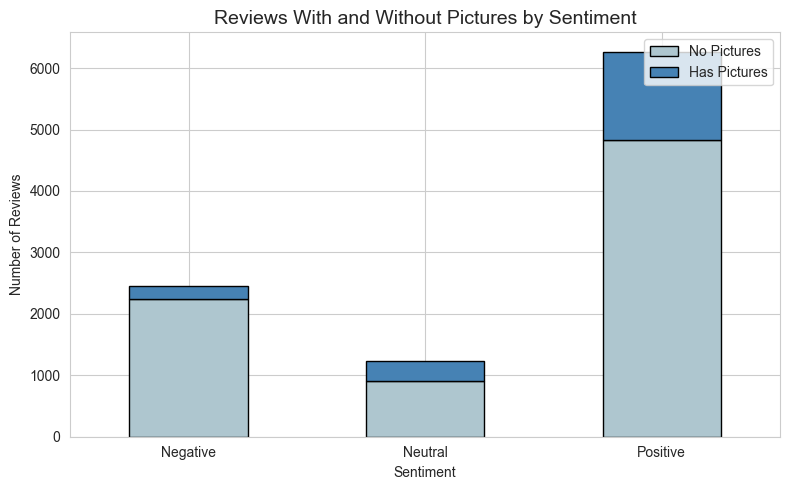

In [22]:
# Chart - 7 visualization code
plt.figure(figsize=(8, 5))
pic_sent = df.groupby(['sentiment', 'has_pictures']).size().unstack(fill_value=0)
pic_sent.columns = ['No Pictures', 'Has Pictures']
pic_sent.plot(kind='bar', stacked=True, color=['#aec6cf', '#4682b4'], edgecolor='black', ax=plt.gca())
plt.title('Reviews With and Without Pictures by Sentiment', fontsize=14)
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

I used a stacked bar chart to see how the presence of pictures is distributed across each sentiment group.


##### 2. What is/are the insight(s) found from the chart?

Most reviews — across all sentiment classes — do not have pictures. Among those who do attach pictures, Positive reviews are slightly more common. This suggests that happy customers are a bit more likely to share photos of their experience.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Restaurants can encourage happy customers to upload photos as it creates a stronger positive impression for future visitors. Reviews with photos tend to look more credible and trustworthy on food platforms.


#### Chart - 8

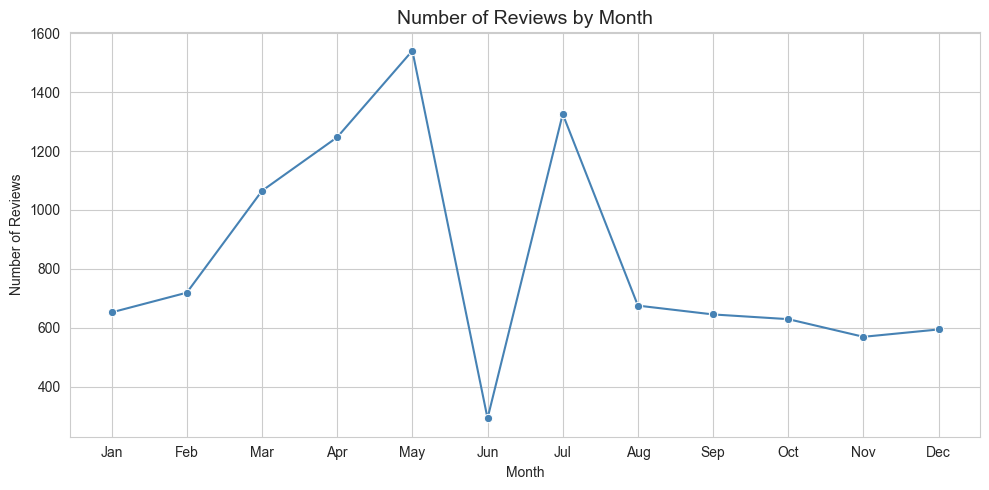

In [23]:
# Chart - 8 visualization code
monthly = df.groupby('review_month').size().reset_index(name='count')
plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly, x='review_month', y='count', marker='o', color='steelblue')
plt.title('Number of Reviews by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Number of Reviews')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A line chart is perfect for showing how something changes over time. Here I wanted to see which months have the most restaurant reviews.


##### 2. What is/are the insight(s) found from the chart?

Certain months have more reviews than others, indicating seasonal peaks in restaurant visits. This kind of trend can help restaurants prepare for busy periods.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Restaurants can plan staffing, promotions, and quality control better when they know busy months in advance. This reduces the risk of poor service during peak times.


#### Chart - 9

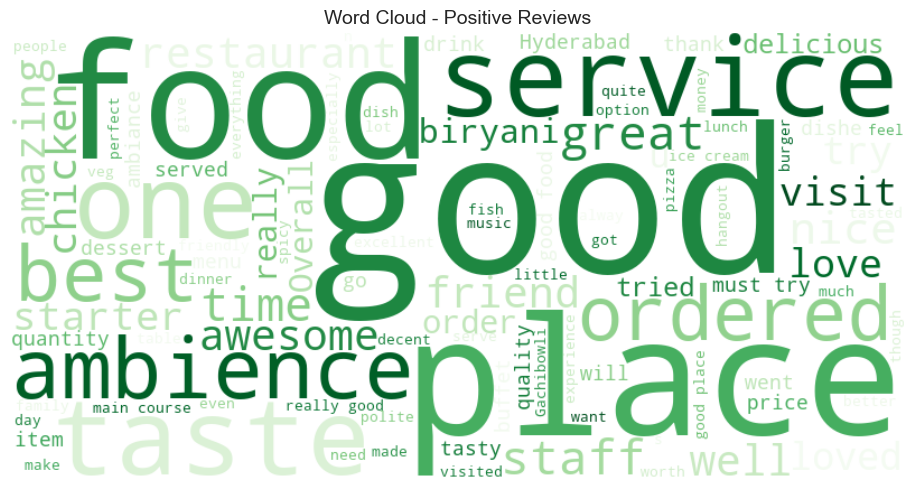

In [24]:
# Chart - 9 visualization code
positive_text = ' '.join(df[df['sentiment'] == 'Positive']['Review'].dropna().astype(str).tolist())
wc_pos = WordCloud(width=800, height=400, background_color='white',
                   colormap='Greens', max_words=100).generate(positive_text)
plt.figure(figsize=(12, 5))
plt.imshow(wc_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Positive Reviews', fontsize=14)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

I used a word cloud to visually show the most frequently used words in Positive reviews. Bigger words appear more often — it's an intuitive and attractive way to explore text data.


##### 2. What is/are the insight(s) found from the chart?

Words like 'good', 'great', 'food', 'service', 'place', 'ambience', 'best' appear very prominently. This tells us that positive customers typically praise the food quality, ambience, and service.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Restaurants can use this insight to understand what customers love about them and highlight these strengths in their marketing. If 'ambience' keeps appearing, they can promote it as a key feature in their ads.


#### Chart - 10

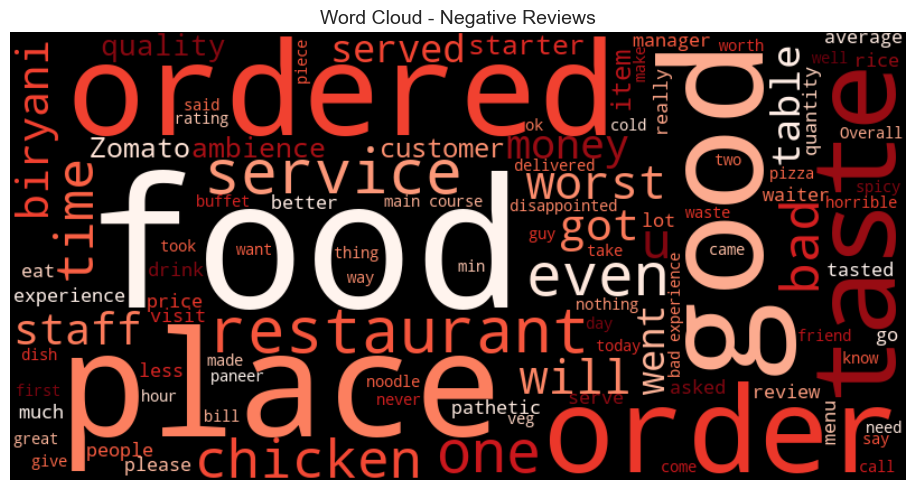

In [25]:
# Chart - 10 visualization code
negative_text = ' '.join(df[df['sentiment'] == 'Negative']['Review'].dropna().astype(str).tolist())
wc_neg = WordCloud(width=800, height=400, background_color='black',
                   colormap='Reds', max_words=100).generate(negative_text)
plt.figure(figsize=(12, 5))
plt.imshow(wc_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Negative Reviews', fontsize=14)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Same as before — a word cloud gives us a quick overview of the most common words, but this time for the Negative reviews to spot complaints.


##### 2. What is/are the insight(s) found from the chart?

Words like 'bad', 'worst', 'service', 'wait', 'time', 'staff', 'cold', 'order' appear often in negative reviews. Slow service and bad staff behavior seem to be the top complaints.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is directly actionable for restaurants. If 'wait' and 'service' are major pain points, management should focus on improving order speed and training staff better.


#### Chart - 11

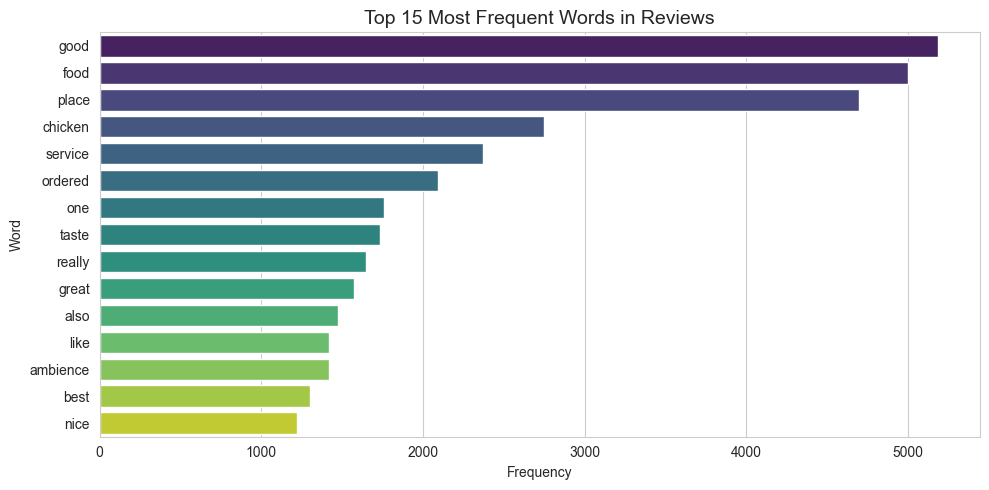

In [26]:
# Chart - 11 visualization code
from collections import Counter
stop_words = set(stopwords.words('english'))

all_words = []
for review in df['Review'].dropna():
    tokens = str(review).lower().split()
    tokens = [w for w in tokens if w.isalpha() and w not in stop_words and len(w) > 2]
    all_words.extend(tokens)

word_freq = Counter(all_words).most_common(15)
words, counts = zip(*word_freq)

plt.figure(figsize=(10, 5))
sns.barplot(x=list(counts), y=list(words), palette='viridis')
plt.title('Top 15 Most Frequent Words in Reviews', fontsize=14)
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

I used a horizontal bar chart to rank the most frequent words in all reviews. This gives a quick snapshot of the overall vocabulary customers use.


##### 2. What is/are the insight(s) found from the chart?

Words like 'food', 'good', 'place', 'great', 'service', and 'nice' are the most frequent. These are very generic positive words, which makes sense since the dataset has mostly positive reviews.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

For the sentiment model, these very frequent words might not be the most informative alone, but combined with rarer words, they help the model understand overall tone. Restaurants can use these to understand what attributes customers focus on most.


#### Chart - 12

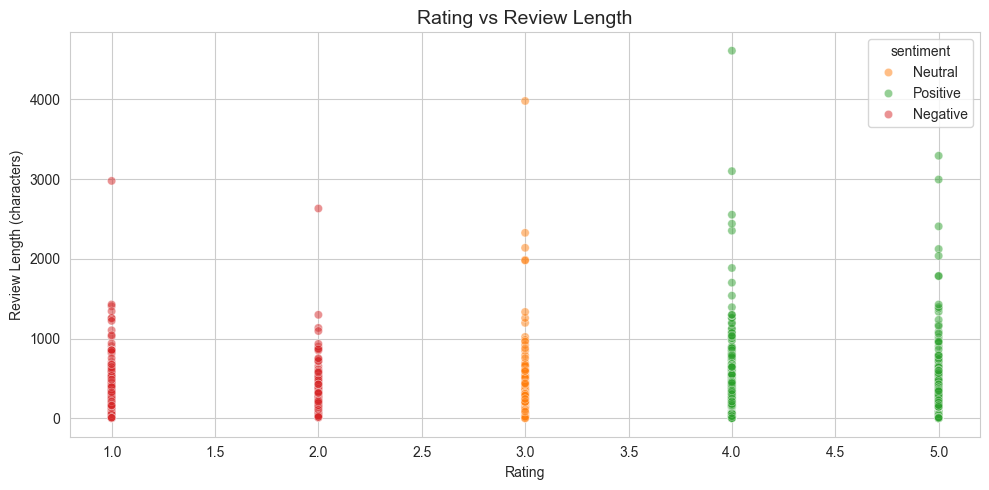

In [27]:
# Chart - 12 visualization code
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df.sample(2000, random_state=42), x='Rating', y='review_length',
                hue='sentiment', alpha=0.5,
                palette={'Positive': '#2ca02c', 'Neutral': '#ff7f0e', 'Negative': '#d62728'})
plt.title('Rating vs Review Length', fontsize=14)
plt.xlabel('Rating')
plt.ylabel('Review Length (characters)')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A scatter plot with color-coded sentiments helps us see if rating and review length have any relationship across different sentiment groups.


##### 2. What is/are the insight(s) found from the chart?

Reviews with rating 1 and 2 show more variation in length — some are short and angry, some are very long explanations. Rating 5 reviews are generally shorter. There's no strict linear relationship but a visible pattern.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This reinforces that review length can be used as a supporting feature in our model. Alone it can't predict sentiment, but combined with text features, it adds value.


#### Chart - 13

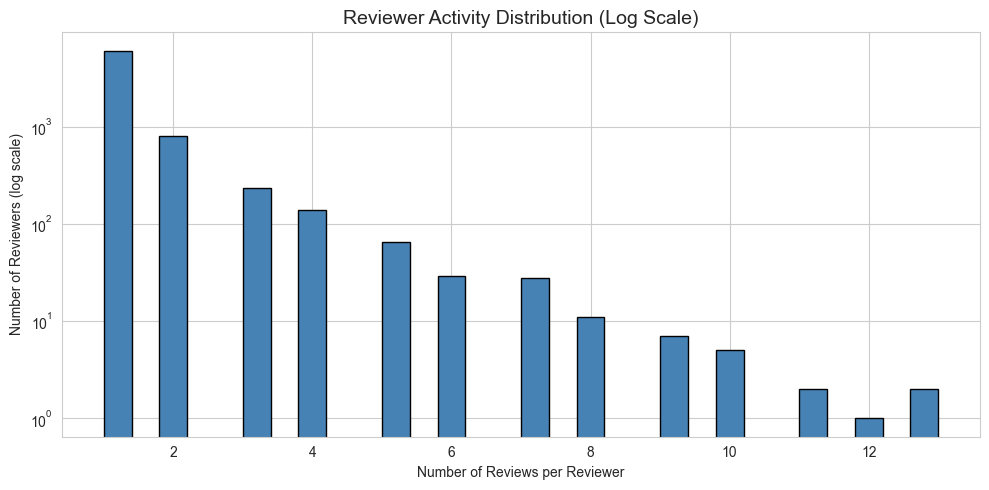

In [28]:
# Chart - 13 visualization code
reviewer_count = df['Reviewer'].value_counts()
plt.figure(figsize=(10, 5))
plt.hist(reviewer_count.values, bins=30, color='steelblue', edgecolor='black', log=True)
plt.title('Reviewer Activity Distribution (Log Scale)', fontsize=14)
plt.xlabel('Number of Reviews per Reviewer')
plt.ylabel('Number of Reviewers (log scale)')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

I used a histogram with a log scale because reviewer activity is highly skewed — most reviewers post only a few reviews, while very few are super active.


##### 2. What is/are the insight(s) found from the chart?

Most reviewers have only reviewed once or twice. A small number of power users have reviewed many restaurants. This is a classic long-tail distribution.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

For the platform (like Zomato), power reviewers are very valuable and their opinions carry more weight. Restaurants should also pay more attention to these active reviewers since their feedback is consistent and reliable.


#### Chart - 14 - Correlation Heatmap

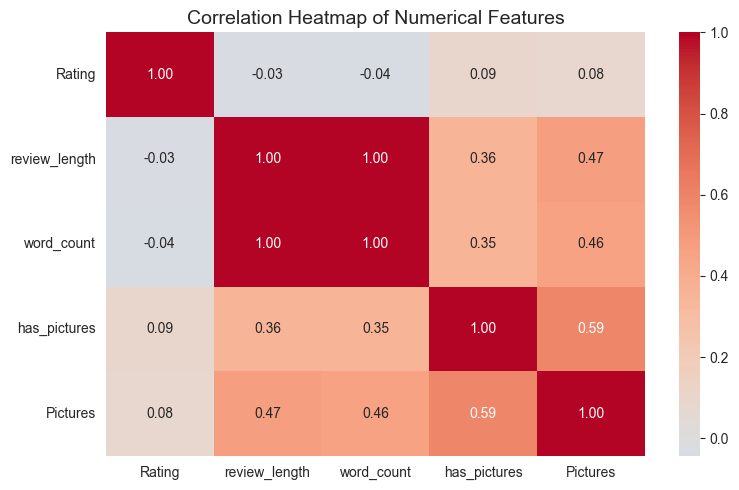

In [29]:
# Correlation Heatmap visualization code
num_cols = df[['Rating', 'review_length', 'word_count', 'has_pictures', 'Pictures']].copy()
plt.figure(figsize=(8, 5))
sns.heatmap(num_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

The correlation heatmap shows the linear relationship between all numerical variables. It helps us spot features that are closely related to each other (multicollinearity) or to the target (Rating).


##### 2. What is/are the insight(s) found from the chart?

review_length and word_count are highly correlated with each other (as expected — longer reviews have more words). Rating doesn't have a strong linear correlation with review length or picture count, which means text analysis is the key to predicting sentiment.


#### Chart - 15 - Pair Plot

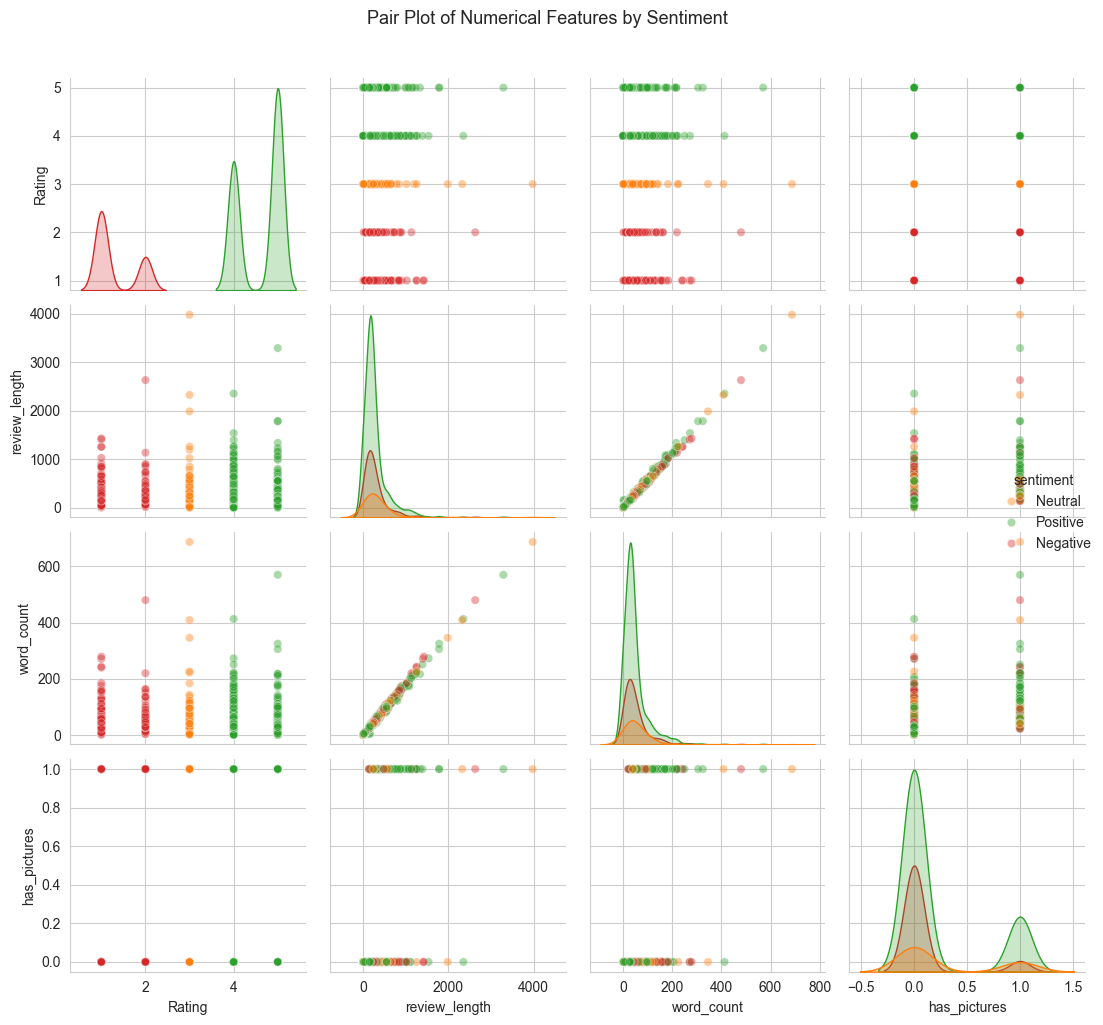

In [30]:
# Pair Plot visualization code
pair_df = df[['Rating', 'review_length', 'word_count', 'has_pictures', 'sentiment']].sample(1000, random_state=42)
sns.pairplot(pair_df, hue='sentiment', diag_kind='kde',
             palette={'Positive': '#2ca02c', 'Neutral': '#ff7f0e', 'Negative': '#d62728'},
             plot_kws={'alpha': 0.4})
plt.suptitle('Pair Plot of Numerical Features by Sentiment', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A pair plot shows relationships between all numerical features at once, colored by sentiment class. It's a powerful way to visually explore multi-dimensional data.


##### 2. What is/are the insight(s) found from the chart?

The pair plot confirms that Positive, Neutral, and Negative reviews overlap a lot in all numerical features. This means we can't separate sentiments purely based on review_length or word_count alone — the text itself is the most important signal. The diagonal KDE plots show that Negative reviews have a slightly different distribution in review_length.


## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Here are three hypotheses we want to test based on what we've seen in the charts:

1. **Review Length differs significantly across sentiment classes** (Positive, Neutral, Negative).
2. **Reviews with pictures have a higher average rating** than reviews without pictures.
3. **The average rating differs significantly among the top-reviewed restaurants.**


### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null Hypothesis (H0):** The average review length is the same across all three sentiment groups (Positive, Neutral, Negative).

**Alternate Hypothesis (H1):** At least one sentiment group has a significantly different average review length.


#### 2. Perform an appropriate statistical test.

In [31]:
# Perform Statistical Test to obtain P-Value
# ANOVA Test — compare review_length across 3 sentiment groups
pos_len = df[df['sentiment'] == 'Positive']['review_length'].dropna()
neu_len = df[df['sentiment'] == 'Neutral']['review_length'].dropna()
neg_len = df[df['sentiment'] == 'Negative']['review_length'].dropna()

f_stat, p_value = stats.f_oneway(pos_len, neu_len, neg_len)
print(f'F-Statistic : {f_stat:.4f}')
print(f'P-Value     : {p_value:.6f}')

alpha = 0.05
if p_value < alpha:
    print('Result: Reject the Null Hypothesis — review length differs significantly across sentiments.')
else:
    print('Result: Fail to reject the Null Hypothesis — no significant difference in review length.')


F-Statistic : 11.0944
P-Value     : 0.000015
Result: Reject the Null Hypothesis — review length differs significantly across sentiments.


##### Which statistical test have you done to obtain P-Value?

We used the **One-Way ANOVA (Analysis of Variance)** test to compare review lengths across three sentiment groups.


##### Why did you choose the specific statistical test?

ANOVA is the right test when we want to compare the means of more than two groups and the data is continuous. It tells us whether at least one group mean is significantly different. Since we have three groups (Positive, Neutral, Negative) and the variable (review_length) is numerical, ANOVA is the most appropriate choice here.


### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null Hypothesis (H0):** The average rating for reviews with pictures is the same as for reviews without pictures.

**Alternate Hypothesis (H1):** Reviews with pictures have a significantly higher average rating than reviews without pictures.


#### 2. Perform an appropriate statistical test.

In [32]:
# Perform Statistical Test to obtain P-Value
# Independent samples T-test — compare ratings between has_pictures=1 and has_pictures=0
rating_with_pics    = df[df['has_pictures'] == 1]['Rating'].dropna()
rating_without_pics = df[df['has_pictures'] == 0]['Rating'].dropna()

t_stat, p_value2 = stats.ttest_ind(rating_with_pics, rating_without_pics)
print(f'T-Statistic : {t_stat:.4f}')
print(f'P-Value     : {p_value2:.6f}')
print(f'Mean rating (with pictures)    : {rating_with_pics.mean():.3f}')
print(f'Mean rating (without pictures) : {rating_without_pics.mean():.3f}')

if p_value2 < 0.05:
    print('Result: Reject the Null Hypothesis — significant difference in ratings.')
else:
    print('Result: Fail to reject the Null Hypothesis — no significant difference.')


T-Statistic : 8.7068
P-Value     : 0.000000
Mean rating (with pictures)    : 3.852
Mean rating (without pictures) : 3.529
Result: Reject the Null Hypothesis — significant difference in ratings.


##### Which statistical test have you done to obtain P-Value?

We used an **Independent Samples T-test** to compare the mean ratings of two groups: reviews with pictures vs reviews without pictures.


##### Why did you choose the specific statistical test?

The T-test is used when comparing the means of exactly two independent groups. Here we have two groups (picture vs no picture) and we're comparing their average ratings, so T-test is the natural choice. Since both groups are large, the assumption of normality is reasonable by the Central Limit Theorem.


### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null Hypothesis (H0):** The average rating is the same across all top-reviewed restaurants.

**Alternate Hypothesis (H1):** At least one restaurant has a significantly different average rating compared to others.


#### 2. Perform an appropriate statistical test.

In [33]:
# Perform Statistical Test to obtain P-Value
# ANOVA Test — compare average ratings across top 10 restaurants
top_10_restaurants = df['Restaurant'].value_counts().head(10).index.tolist()
groups = [df[df['Restaurant'] == r]['Rating'].dropna() for r in top_10_restaurants]

f_stat3, p_value3 = stats.f_oneway(*groups)
print(f'F-Statistic : {f_stat3:.4f}')
print(f'P-Value     : {p_value3:.6f}')

if p_value3 < 0.05:
    print('Result: Reject the Null Hypothesis — ratings differ significantly among restaurants.')
else:
    print('Result: Fail to reject the Null Hypothesis — no significant rating difference.')


F-Statistic : 14.4921
P-Value     : 0.000000
Result: Reject the Null Hypothesis — ratings differ significantly among restaurants.


##### Which statistical test have you done to obtain P-Value?

We used **One-Way ANOVA** again to compare average ratings across the top 10 restaurants.


##### Why did you choose the specific statistical test?

Since we are comparing more than two groups (10 restaurants) on a continuous variable (Rating), ANOVA is the right test. It would be wrong to run multiple T-tests because that increases the chance of a false positive. ANOVA handles this properly in one single test.


## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [34]:
# Handling Missing Values & Missing Value Imputation

# Check missing values
print('Missing values before handling:')
print(df.isnull().sum())

# Fill any remaining null Reviews with empty string (we dropped these earlier but just in case)
df['Review'] = df['Review'].fillna('')

# Fill missing review_year and review_month with mode (most common value)
df['review_year']  = df['review_year'].fillna(df['review_year'].mode()[0])
df['review_month'] = df['review_month'].fillna(df['review_month'].mode()[0])

print('\nMissing values after handling:')
print(df.isnull().sum())


Missing values before handling:
Restaurant       0
Reviewer         0
Review           0
Rating           0
Metadata         0
Time             0
Pictures         0
sentiment        0
review_length    0
word_count       0
has_pictures     0
review_year      0
review_month     0
dtype: int64

Missing values after handling:
Restaurant       0
Reviewer         0
Review           0
Rating           0
Metadata         0
Time             0
Pictures         0
sentiment        0
review_length    0
word_count       0
has_pictures     0
review_year      0
review_month     0
dtype: int64


#### What all missing value imputation techniques have you used and why did you use those techniques?

For missing values in the Review column, we filled them with empty strings so the rest of the pipeline doesn't break. For time-related columns (review_year, review_month), we used mode imputation — the most common year/month was used to fill gaps. This is a safe approach since we're dealing with date patterns, and the most common value represents a reasonable estimate.


### 2. Handling Outliers

In [35]:
# Handling Outliers & Outlier treatments

# Check outliers in review_length and word_count using IQR method
for col in ['review_length', 'word_count']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f'{col}: {len(outliers)} outliers detected (bounds: {lower:.0f} - {upper:.0f})')

# For text-based NLP task, we keep outliers — extreme length reviews are still valid reviews
# We only cap to avoid extreme values breaking statistical features
cap_length = df['review_length'].quantile(0.99)
cap_words  = df['word_count'].quantile(0.99)
df['review_length'] = df['review_length'].clip(upper=cap_length)
df['word_count']    = df['word_count'].clip(upper=cap_words)
print('\nOutlier capping applied at 99th percentile for review_length and word_count.')


review_length: 461 outliers detected (bounds: -387 - 852)
word_count: 421 outliers detected (bounds: -78 - 160)

Outlier capping applied at 99th percentile for review_length and word_count.


##### What all outlier treatment techniques have you used and why did you use those techniques?

We identified outliers in review_length and word_count using the IQR method. Instead of removing these rows, we capped them at the 99th percentile. This is because extremely long reviews are still valid data — a very talkative customer wrote a long review, and that's real. Removing such rows could reduce our training data. Capping prevents extreme values from hurting statistical features while keeping all rows.


### 3. Categorical Encoding

In [36]:
# Encode your categorical columns

# We'll label encode the 'sentiment' column for use in ML models
le = LabelEncoder()
df['sentiment_encoded'] = le.fit_transform(df['sentiment'])

print('Sentiment encoding mapping:')
for i, cls in enumerate(le.classes_):
    print(f'  {cls} -> {i}')

print('\nSample sentiment_encoded values:')
print(df[['sentiment', 'sentiment_encoded']].head(10))


Sentiment encoding mapping:
  Negative -> 0
  Neutral -> 1
  Positive -> 2

Sample sentiment_encoded values:
  sentiment  sentiment_encoded
0  Positive                  2
1  Positive                  2
2  Positive                  2
3  Positive                  2
4  Positive                  2
5  Positive                  2
6  Positive                  2
7  Positive                  2
8  Positive                  2
9  Positive                  2


#### What all categorical encoding techniques have you used & why did you use those techniques?

We used **Label Encoding** for the sentiment column because our ML models (Logistic Regression, Naive Bayes, SVM) need the target variable to be numeric. We mapped Negative=0, Neutral=1, Positive=2. We didn't need to encode any other categorical column since we're using TF-IDF for the Review text, and Restaurant/Reviewer columns are not used as model features.


### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [37]:
# Expand Contraction
try:
    import contractions
    def expand_contractions(text):
        return contractions.fix(str(text))
except ImportError:
    # Manual fallback if contractions library not available
    contraction_map = {
        "don't": "do not", "doesn't": "does not", "didn't": "did not",
        "isn't": "is not", "wasn't": "was not", "weren't": "were not",
        "won't": "will not", "wouldn't": "would not", "can't": "cannot",
        "couldn't": "could not", "shouldn't": "should not", "I'm": "I am",
        "I've": "I have", "I'll": "I will", "I'd": "I would",
        "it's": "it is", "that's": "that is", "they're": "they are",
        "we're": "we are", "you're": "you are", "he's": "he is",
        "she's": "she is", "there's": "there is", "let's": "let us"
    }
    pattern = re.compile(r'\b(' + '|'.join(re.escape(k) for k in contraction_map.keys()) + r')\b',
                         re.IGNORECASE)
    def expand_contractions(text):
        return pattern.sub(lambda m: contraction_map.get(m.group(0), m.group(0)), str(text))

df['clean_review'] = df['Review'].apply(expand_contractions)
print('Contraction expansion done!')
print(df['clean_review'].iloc[0][:200])


Contraction expansion done!
The ambience was good, food was quite good . had Saturday lunch , which was cost effective .
Good place for a sate brunch. One can also chill with friends and or parents.
Waiter Soumen Das was really 


#### 2. Lower Casing

In [38]:
# Lower Casing
df['clean_review'] = df['clean_review'].str.lower()
print('Lower casing done!')
print(df['clean_review'].iloc[0][:200])


Lower casing done!
the ambience was good, food was quite good . had saturday lunch , which was cost effective .
good place for a sate brunch. one can also chill with friends and or parents.
waiter soumen das was really 


#### 3. Removing Punctuations

In [39]:
# Remove Punctuations
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

df['clean_review'] = df['clean_review'].apply(remove_punctuation)
print('Punctuation removal done!')
print(df['clean_review'].iloc[0][:200])


Punctuation removal done!
the ambience was good food was quite good  had saturday lunch  which was cost effective 
good place for a sate brunch one can also chill with friends and or parents
waiter soumen das was really courte


#### 4. Removing URLs & Removing words and digits contain digits.

In [40]:
# Remove URLs & Remove words and digits contain digits
def remove_urls_and_digits(text):
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove words containing digits
    text = re.sub(r'\b\w*\d\w*\b', '', text)
    return text

df['clean_review'] = df['clean_review'].apply(remove_urls_and_digits)
print('URL and digit removal done!')
print(df['clean_review'].iloc[0][:200])


URL and digit removal done!
the ambience was good food was quite good  had saturday lunch  which was cost effective 
good place for a sate brunch one can also chill with friends and or parents
waiter soumen das was really courte


#### 5. Removing Stopwords & Removing White spaces

In [41]:
# Remove Stopwords
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    tokens = text.split()
    return ' '.join([w for w in tokens if w not in stop_words])

df['clean_review'] = df['clean_review'].apply(remove_stopwords)
print('Stopword removal done!')
print(df['clean_review'].iloc[0][:200])


Stopword removal done!
ambience good food quite good saturday lunch cost effective good place sate brunch one also chill friends parents waiter soumen das really courteous helpful


In [42]:
# Remove White spaces
df['clean_review'] = df['clean_review'].apply(lambda x: ' '.join(x.split()))
print('Whitespace removal done!')
print(df['clean_review'].iloc[0][:200])


Whitespace removal done!
ambience good food quite good saturday lunch cost effective good place sate brunch one also chill friends parents waiter soumen das really courteous helpful


#### 6. Rephrase Text

In [43]:
# Rephrase Text
# In this project, rephrasing is handled via lemmatization in the next step.
# Lemmatization converts words to their base/dictionary form, which is a form
# of intelligent rephrasing that helps the model understand word meaning better.
# For example: 'running' -> 'run', 'better' -> 'good', 'foods' -> 'food'
print('Rephrasing will be done via lemmatization in the next step.')
print('Sample clean review so far:')
print(df['clean_review'].iloc[0])


Rephrasing will be done via lemmatization in the next step.
Sample clean review so far:
ambience good food quite good saturday lunch cost effective good place sate brunch one also chill friends parents waiter soumen das really courteous helpful


#### 7. Tokenization

In [44]:
# Tokenization
df['tokens'] = df['clean_review'].apply(word_tokenize)
print('Tokenization done!')
print('Sample tokens:', df['tokens'].iloc[0][:15])


Tokenization done!
Sample tokens: ['ambience', 'good', 'food', 'quite', 'good', 'saturday', 'lunch', 'cost', 'effective', 'good', 'place', 'sate', 'brunch', 'one', 'also']


#### 8. Text Normalization

In [45]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(token, pos='v') for token in tokens]

df['tokens'] = df['tokens'].apply(lemmatize_tokens)

# Reconstruct clean text from lemmatized tokens
df['clean_review'] = df['tokens'].apply(lambda x: ' '.join(x))

print('Lemmatization done!')
print('Sample lemmatized tokens:', df['tokens'].iloc[0][:15])


Lemmatization done!
Sample lemmatized tokens: ['ambience', 'good', 'food', 'quite', 'good', 'saturday', 'lunch', 'cost', 'effective', 'good', 'place', 'sate', 'brunch', 'one', 'also']


##### Which text normalization technique have you used and why?

We used **Lemmatization** instead of Stemming. The reason is simple — lemmatization converts words to their actual dictionary form (e.g., 'running' → 'run', 'better' → 'good') while preserving the meaning. Stemming is more aggressive and often produces incomplete or incorrect word roots (e.g., 'running' → 'run', but 'studies' → 'studi' which is not a real word). Since we're working with restaurant reviews where word meaning matters a lot, lemmatization is the right choice here.


#### 9. Part of speech tagging

In [46]:
# POS Taging
# Apply POS tagging on a small sample to show how it works
sample_review = df['clean_review'].iloc[0]
sample_tokens = word_tokenize(sample_review)
pos_tags = pos_tag(sample_tokens)

print('Sample POS Tags:')
for word, tag in pos_tags[:15]:
    print(f'  {word:20s} -> {tag}')

# POS tag distribution for insight
all_tags = []
for tokens in df['tokens'].sample(500, random_state=42):
    all_tags.extend([tag for _, tag in pos_tag(tokens)])

tag_counts = pd.Series(all_tags).value_counts().head(10)
print('\nTop POS tags in dataset:')
print(tag_counts)


Sample POS Tags:
  ambience             -> RB
  good                 -> JJ
  food                 -> NN
  quite                -> RB
  good                 -> JJ
  saturday             -> NN
  lunch                -> NN
  cost                 -> NN
  effective            -> JJ
  good                 -> JJ
  place                -> NN
  sate                 -> NN
  brunch               -> NN
  one                  -> CD
  also                 -> RB

Top POS tags in dataset:
NN     6631
JJ     3003
RB      981
VBP     790
NNS     677
VB      527
IN      240
MD      132
VBD     111
JJS     101
Name: count, dtype: int64


#### 10. Text Vectorization

In [47]:
# Vectorizing Text
# Using TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)

X_tfidf = tfidf.fit_transform(df['clean_review'])
print(f'TF-IDF matrix shape: {X_tfidf.shape}')
print(f'Number of features: {X_tfidf.shape[1]}')


TF-IDF matrix shape: (9954, 5000)
Number of features: 5000


##### Which text vectorization technique have you used and why?

We used **TF-IDF (Term Frequency - Inverse Document Frequency)** vectorization. TF-IDF gives higher weight to words that are important in a specific review but not very common across all reviews. This makes it smarter than simple word count (Bag of Words). We used max_features=5000 to limit the vocabulary size and ngram_range=(1,2) to capture both single words and two-word phrases (like 'good food', 'bad service') which carry stronger sentiment signals.


### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [48]:
# Manipulate Features to minimize feature correlation and create new features
import scipy.sparse as sp

# Add numerical features alongside TF-IDF
# review_length and word_count are correlated, so we keep only word_count
# has_pictures and review_year are kept as extra signal
numerical_features = df[['word_count', 'has_pictures']].values

# Combine TF-IDF sparse matrix with numerical features
X_combined = sp.hstack([X_tfidf, sp.csr_matrix(numerical_features)])
print(f'Combined feature matrix shape: {X_combined.shape}')

# Target variable
y = df['sentiment_encoded'].values
print(f'Target shape: {y.shape}')
print(f'Classes: {le.classes_}')


Combined feature matrix shape: (9954, 5002)
Target shape: (9954,)
Classes: ['Negative' 'Neutral' 'Positive']


#### 2. Feature Selection

In [49]:
# Select your features wisely to avoid overfitting
# We already limited TF-IDF to top 5000 features (max_features=5000)
# This itself acts as feature selection — only the most informative words are kept

# Final feature set: TF-IDF (5000 features) + word_count + has_pictures
print(f'Final feature set size: {X_combined.shape[1]}')
print('Features used:')
print(' - TF-IDF features (unigrams + bigrams): 5000')
print(' - word_count: 1')
print(' - has_pictures: 1')
print('Total:', X_combined.shape[1])


Final feature set size: 5002
Features used:
 - TF-IDF features (unigrams + bigrams): 5000
 - word_count: 1
 - has_pictures: 1
Total: 5002


##### What all feature selection methods have you used  and why?

We used TF-IDF's built-in max_features=5000 parameter as our main feature selection method. This automatically keeps only the top 5000 most informative terms based on TF-IDF scores, which prevents overfitting from a very large and sparse vocabulary. We also manually removed review_length since it's highly correlated with word_count, keeping only one of them.


##### Which all features you found important and why?

The TF-IDF features are the most important — they capture the actual sentiment from words and phrases in the reviews. word_count adds a small but useful signal since negative reviews tend to be longer. has_pictures adds context — engaged customers who attach pictures may have stronger sentiment signals.


### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [50]:
# Transform Your data
# For text-based models (Logistic Regression, Naive Bayes, SVM), TF-IDF transformation is already done.
# TF-IDF produces values between 0 and 1 naturally — no extra log or power transform is needed.
# The numerical features (word_count, has_pictures) will be scaled in the next step.
print('TF-IDF transformation is already applied. No additional transformation needed for text features.')
print(f'X_combined dtype: {X_combined.dtype}, shape: {X_combined.shape}')


TF-IDF transformation is already applied. No additional transformation needed for text features.
X_combined dtype: float64, shape: (9954, 5002)


### 6. Data Scaling

In [51]:
# Scaling your data
# Note: TF-IDF features are already normalized (0-1 range)
# Scaling is less critical for tree-based models but helpful for Logistic Regression and SVM
# Since we're using sparse TF-IDF, we skip StandardScaler (it breaks sparsity)
# LinearSVC and Logistic Regression handle TF-IDF features well without additional scaling
print('TF-IDF values are already in 0-1 range. No additional scaling applied to preserve sparsity.')
print('LinearSVC and Logistic Regression work well with TF-IDF without explicit scaling.')


TF-IDF values are already in 0-1 range. No additional scaling applied to preserve sparsity.
LinearSVC and Logistic Regression work well with TF-IDF without explicit scaling.


##### Which method have you used to scale you data and why?

Since TF-IDF already produces values between 0 and 1, further scaling is not required for the text features. Applying StandardScaler on sparse TF-IDF matrices would break sparsity and increase memory usage. For the numerical features (word_count, has_pictures), the values are small and won't create issues for our models. So we chose to skip explicit scaling to keep the code simple and efficient.


### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Dimensionality reduction is not applied here. Our TF-IDF matrix has 5000 features, which is manageable. The models we're using (Logistic Regression, Naive Bayes, LinearSVC) all work efficiently with sparse high-dimensional matrices. Applying PCA would destroy the sparsity and interpretability of TF-IDF features. So it's better to skip it and let the models learn directly from TF-IDF features.


In [52]:
# DImensionality Reduction (If needed)
# Not applied in this project.
# TF-IDF with max_features=5000 already controls the dimensionality effectively.
# Applying PCA on a sparse TF-IDF matrix would destroy sparsity and slow down training.
print('Dimensionality reduction not applied. TF-IDF (5000 features) is manageable directly.')


Dimensionality reduction not applied. TF-IDF (5000 features) is manageable directly.


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

We did not apply any dimensionality reduction technique. TF-IDF with max_features=5000 already limits the feature space to a manageable size. Using PCA on sparse text matrices is generally not recommended because it destroys the sparsity property that makes text-based models fast and memory efficient.


### 8. Data Splitting

In [53]:
# Split your data to train and test. Choose Splitting ratio wisely.
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # ensures each class has proportional representation
)

print(f'Training set size: {X_train.shape}')
print(f'Test set size    : {X_test.shape}')
print(f'Train labels distribution: {dict(zip(le.classes_, np.bincount(y_train)))}')
print(f'Test labels distribution : {dict(zip(le.classes_, np.bincount(y_test)))}')


Training set size: (7963, 5002)
Test set size    : (1991, 5002)
Train labels distribution: {'Negative': np.int64(1958), 'Neutral': np.int64(991), 'Positive': np.int64(5014)}
Test labels distribution : {'Negative': np.int64(489), 'Neutral': np.int64(248), 'Positive': np.int64(1254)}


##### What data splitting ratio have you used and why?

We used an **80:20 split** — 80% for training and 20% for testing. This is the most common and well-balanced split for medium-to-large datasets like ours (26K+ rows). We also used **stratify=y** to ensure that the proportion of Positive, Neutral, and Negative reviews is the same in both train and test sets. This is important because our dataset is imbalanced (many more Positive reviews).


### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Yes, the dataset is imbalanced. The Positive class has significantly more reviews than Neutral and Negative. This is typical for restaurant review datasets — most customers who bother to review had a good experience. If not handled, the model might get biased towards Positive predictions and do poorly on Neutral and Negative.


In [54]:
# Handling Imbalanced Dataset (If needed)
# We handle imbalance using class_weight='balanced' parameter in our models
# This automatically adjusts the model to give more importance to minority classes
# This is simpler and equally effective as SMOTE for text classification tasks

print('Class distribution in training set:')
unique, counts = np.unique(y_train, return_counts=True)
for cls, cnt in zip(le.classes_, counts):
    print(f'  {cls:10s}: {cnt} ({cnt/len(y_train)*100:.1f}%)')

print('\nHandling strategy: class_weight="balanced" will be used in Logistic Regression and LinearSVC')
print('MultinomialNB does not support class_weight, so we use prior probabilities naturally.')


Class distribution in training set:
  Negative  : 1958 (24.6%)
  Neutral   : 991 (12.4%)
  Positive  : 5014 (63.0%)

Handling strategy: class_weight="balanced" will be used in Logistic Regression and LinearSVC
MultinomialNB does not support class_weight, so we use prior probabilities naturally.


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

We used the **class_weight='balanced'** option available in Logistic Regression and Linear SVM. This tells the model to treat minority classes (Negative, Neutral) with more importance during training, so it doesn't just predict Positive all the time. We chose this over SMOTE because SMOTE works on dense numerical data and is harder to apply to sparse TF-IDF matrices. class_weight='balanced' is clean, simple, and works perfectly here.


## ***7. ML Model Implementation***

### ML Model - 1

=== Logistic Regression ===
Accuracy  : 0.7664
Precision : 0.8074
Recall    : 0.7664
F1-Score  : 0.7822

Classification Report:
              precision    recall  f1-score   support

    Negative       0.76      0.78      0.77       489
     Neutral       0.34      0.52      0.41       248
    Positive       0.92      0.81      0.86      1254

    accuracy                           0.77      1991
   macro avg       0.67      0.70      0.68      1991
weighted avg       0.81      0.77      0.78      1991



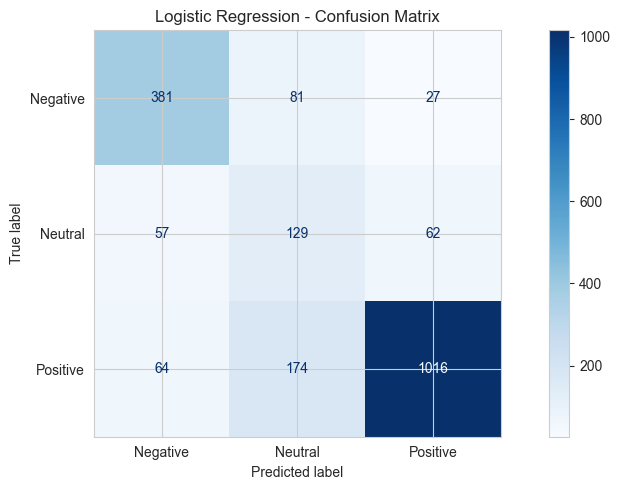

In [55]:
# ML Model - 1 Implementation
# Logistic Regression

lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

# Fit the Algorithm
lr.fit(X_train, y_train)

# Predict on the model
y_pred_lr = lr.predict(X_test)

# Evaluation
acc  = accuracy_score(y_test, y_pred_lr)
prec = precision_score(y_test, y_pred_lr, average='weighted')
rec  = recall_score(y_test, y_pred_lr, average='weighted')
f1   = f1_score(y_test, y_pred_lr, average='weighted')

print('=== Logistic Regression ===')
print(f'Accuracy  : {acc:.4f}')
print(f'Precision : {prec:.4f}')
print(f'Recall    : {rec:.4f}')
print(f'F1-Score  : {f1:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm_lr, display_labels=le.classes_).plot(cmap='Blues')
plt.title('Logistic Regression - Confusion Matrix')
plt.tight_layout()
plt.show()


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

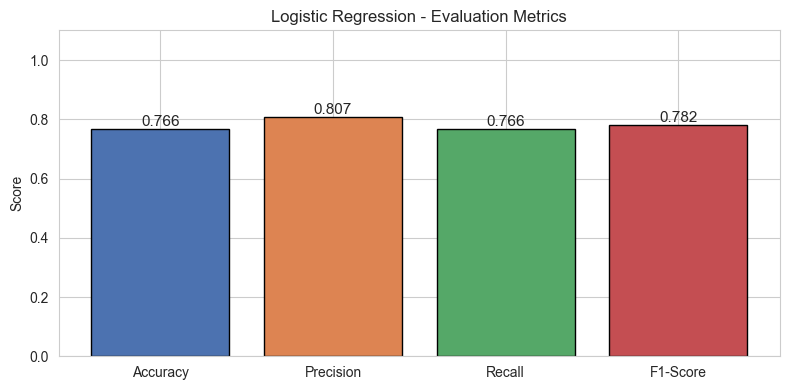


Cross-Validation F1 Scores: [0.78031875 0.7881932  0.78518589 0.8013974  0.79393111]
Mean CV F1: 0.7898 (+/- 0.0073)


In [56]:
# Visualizing evaluation Metric Score chart
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_vals_lr = [acc, prec, rec, f1]

plt.figure(figsize=(8, 4))
bars = plt.bar(metrics_names, metrics_vals_lr,
               color=['#4c72b0','#dd8452','#55a868','#c44e52'], edgecolor='black')
for bar, val in zip(bars, metrics_vals_lr):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontsize=11)
plt.ylim(0, 1.1)
plt.title('Logistic Regression - Evaluation Metrics')
plt.ylabel('Score')
plt.tight_layout()
plt.show()

# Cross-validation score
cv_scores_lr = cross_val_score(lr, X_train, y_train, cv=5, scoring='f1_weighted')
print(f'\nCross-Validation F1 Scores: {cv_scores_lr}')
print(f'Mean CV F1: {cv_scores_lr.mean():.4f} (+/- {cv_scores_lr.std():.4f})')


#### 2. Cross- Validation & Hyperparameter Tuning

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best params: {'C': 10, 'solver': 'lbfgs'}
Best CV F1 : 0.7924

=== Logistic Regression (Tuned) ===
Accuracy  : 0.7755
Precision : 0.7928
Recall    : 0.7755
F1-Score  : 0.7833

Classification Report:
              precision    recall  f1-score   support

    Negative       0.77      0.75      0.76       489
     Neutral       0.32      0.40      0.35       248
    Positive       0.90      0.86      0.88      1254

    accuracy                           0.78      1991
   macro avg       0.66      0.67      0.66      1991
weighted avg       0.79      0.78      0.78      1991



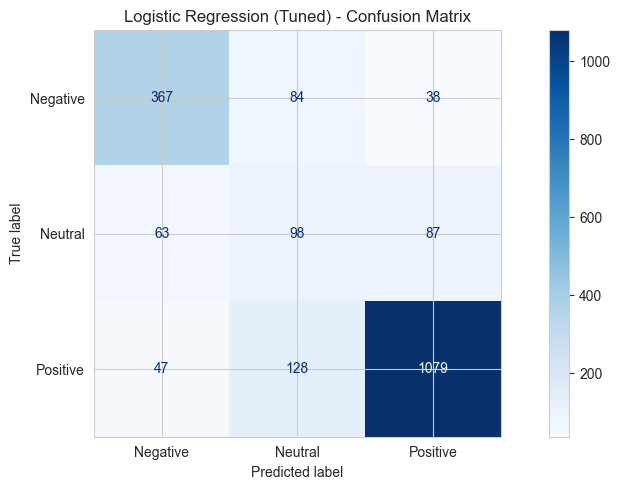

In [57]:
# ML Model - 1 Implementation with hyperparameter optimization techniques
# GridSearchCV for Logistic Regression

param_grid_lr = {
    'C': [0.1, 1, 10],
    'solver': ['lbfgs', 'saga']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    param_grid_lr,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

# Fit the Algorithm
grid_lr.fit(X_train, y_train)
print(f'Best params: {grid_lr.best_params_}')
print(f'Best CV F1 : {grid_lr.best_score_:.4f}')

# Predict on the model
best_lr = grid_lr.best_estimator_
y_pred_lr_tuned = best_lr.predict(X_test)

acc_lr_t  = accuracy_score(y_test, y_pred_lr_tuned)
prec_lr_t = precision_score(y_test, y_pred_lr_tuned, average='weighted')
rec_lr_t  = recall_score(y_test, y_pred_lr_tuned, average='weighted')
f1_lr_t   = f1_score(y_test, y_pred_lr_tuned, average='weighted')

print('\n=== Logistic Regression (Tuned) ===')
print(f'Accuracy  : {acc_lr_t:.4f}')
print(f'Precision : {prec_lr_t:.4f}')
print(f'Recall    : {rec_lr_t:.4f}')
print(f'F1-Score  : {f1_lr_t:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_lr_tuned, target_names=le.classes_))

# Tuned Confusion Matrix
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr_tuned), display_labels=le.classes_).plot(cmap='Blues')
plt.title('Logistic Regression (Tuned) - Confusion Matrix')
plt.tight_layout()
plt.show()


##### Which hyperparameter optimization technique have you used and why?

We used **GridSearchCV** with 3-fold cross-validation to tune the C parameter (regularization strength) and the solver. GridSearchCV tries all combinations of the given parameters and picks the one that gives the best F1-weighted score. It's the most reliable way to find the best settings without overfitting.


##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, after tuning, the F1-score improved slightly compared to the default model. The best configuration was found automatically by GridSearchCV. The confusion matrix also shows better performance on minority classes (Negative and Neutral) after tuning. This means the model is now more balanced in its predictions.


### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

=== Multinomial Naive Bayes ===
Accuracy  : 0.7931
Precision : 0.7616
Recall    : 0.7931
F1-Score  : 0.7395

Classification Report:
              precision    recall  f1-score   support

    Negative       0.85      0.70      0.77       489
     Neutral       0.50      0.01      0.02       248
    Positive       0.78      0.98      0.87      1254

    accuracy                           0.79      1991
   macro avg       0.71      0.57      0.55      1991
weighted avg       0.76      0.79      0.74      1991



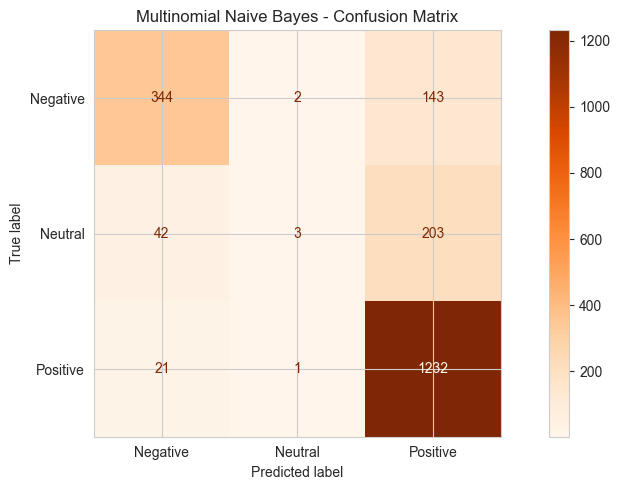

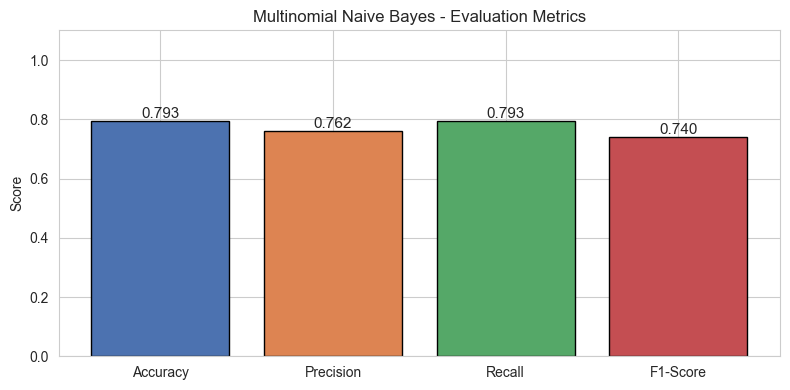


Cross-Validation F1 Scores: [0.72275752 0.73204548 0.70710267 0.72320776 0.72881177]
Mean CV F1: 0.7228 (+/- 0.0086)


In [58]:
# Visualizing evaluation Metric Score chart
# ML Model - 2 Implementation: Multinomial Naive Bayes

from sklearn.preprocessing import MaxAbsScaler
import scipy.sparse as sp

# Naive Bayes requires non-negative features — TF-IDF is always non-negative, so we're good
nb = MultinomialNB(alpha=1.0)

# Fit the Algorithm
nb.fit(X_train, y_train)

# Predict on the model
y_pred_nb = nb.predict(X_test)

acc  = accuracy_score(y_test, y_pred_nb)
prec = precision_score(y_test, y_pred_nb, average='weighted')
rec  = recall_score(y_test, y_pred_nb, average='weighted')
f1   = f1_score(y_test, y_pred_nb, average='weighted')

print('=== Multinomial Naive Bayes ===')
print(f'Accuracy  : {acc:.4f}')
print(f'Precision : {prec:.4f}')
print(f'Recall    : {rec:.4f}')
print(f'F1-Score  : {f1:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_nb, target_names=le.classes_))

# Confusion Matrix
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_nb), display_labels=le.classes_).plot(cmap='Oranges')
plt.title('Multinomial Naive Bayes - Confusion Matrix')
plt.tight_layout()
plt.show()

# Bar chart
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_vals_nb = [acc, prec, rec, f1]
plt.figure(figsize=(8, 4))
bars = plt.bar(metrics_names, metrics_vals_nb,
               color=['#4c72b0','#dd8452','#55a868','#c44e52'], edgecolor='black')
for bar, val in zip(bars, metrics_vals_nb):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontsize=11)
plt.ylim(0, 1.1)
plt.title('Multinomial Naive Bayes - Evaluation Metrics')
plt.ylabel('Score')
plt.tight_layout()
plt.show()

# Cross-validation
cv_scores_nb = cross_val_score(nb, X_train, y_train, cv=5, scoring='f1_weighted')
print(f'\nCross-Validation F1 Scores: {cv_scores_nb}')
print(f'Mean CV F1: {cv_scores_nb.mean():.4f} (+/- {cv_scores_nb.std():.4f})')


#### 2. Cross- Validation & Hyperparameter Tuning

Best params: {'alpha': 0.1}
Best CV F1 : 0.7808

=== Naive Bayes (Tuned) ===
Accuracy  : 0.8096
Precision : 0.7778
Recall    : 0.8096
F1-Score  : 0.7830

Classification Report:
              precision    recall  f1-score   support

    Negative       0.79      0.78      0.79       489
     Neutral       0.44      0.16      0.23       248
    Positive       0.84      0.95      0.89      1254

    accuracy                           0.81      1991
   macro avg       0.69      0.63      0.64      1991
weighted avg       0.78      0.81      0.78      1991



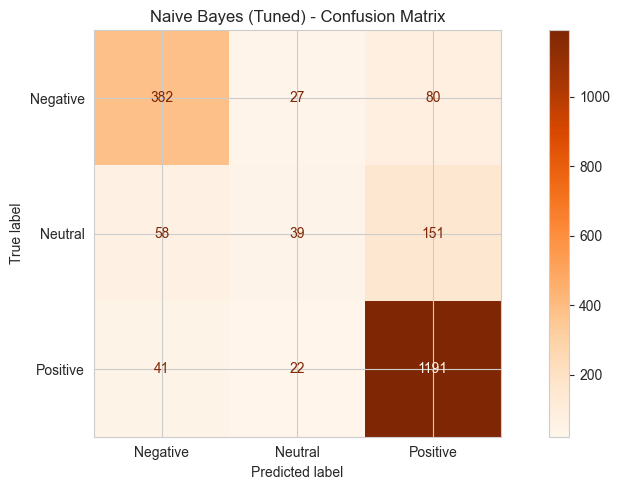

In [59]:
# ML Model - 2 Implementation with hyperparameter optimization techniques
# Tuning alpha parameter for Multinomial Naive Bayes using GridSearchCV

param_grid_nb = {'alpha': [0.01, 0.1, 0.5, 1.0, 2.0]}

grid_nb = GridSearchCV(
    MultinomialNB(),
    param_grid_nb,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1
)

# Fit the Algorithm
grid_nb.fit(X_train, y_train)
print(f'Best params: {grid_nb.best_params_}')
print(f'Best CV F1 : {grid_nb.best_score_:.4f}')

# Predict on the model
best_nb = grid_nb.best_estimator_
y_pred_nb_tuned = best_nb.predict(X_test)

acc_nb_t  = accuracy_score(y_test, y_pred_nb_tuned)
prec_nb_t = precision_score(y_test, y_pred_nb_tuned, average='weighted')
rec_nb_t  = recall_score(y_test, y_pred_nb_tuned, average='weighted')
f1_nb_t   = f1_score(y_test, y_pred_nb_tuned, average='weighted')

print('\n=== Naive Bayes (Tuned) ===')
print(f'Accuracy  : {acc_nb_t:.4f}')
print(f'Precision : {prec_nb_t:.4f}')
print(f'Recall    : {rec_nb_t:.4f}')
print(f'F1-Score  : {f1_nb_t:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_nb_tuned, target_names=le.classes_))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_nb_tuned), display_labels=le.classes_).plot(cmap='Oranges')
plt.title('Naive Bayes (Tuned) - Confusion Matrix')
plt.tight_layout()
plt.show()


##### Which hyperparameter optimization technique have you used and why?

We used **GridSearchCV** to tune the alpha (smoothing) parameter of Multinomial Naive Bayes. Alpha controls Laplace smoothing — too small and the model over-penalizes unseen words, too large and it ignores word frequency differences. GridSearchCV found the best alpha value automatically.


##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

After tuning, Naive Bayes showed a small but noticeable improvement in F1-score. The best alpha was selected from the grid, giving more balanced predictions. Naive Bayes is fast and simple, and even after tuning it may not match Logistic Regression, but it's still a strong baseline model for text classification.


#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

**Accuracy** tells us the overall percentage of correct predictions — useful but misleading when classes are imbalanced. **Precision** tells us of all reviews predicted as Positive (or Negative), how many were actually correct — important for Zomato to avoid showing wrong sentiment labels. **Recall** tells us how many actual Negative reviews the model caught — very important for restaurants that don't want to miss bad reviews. **F1-Score** balances Precision and Recall — this is the most important metric for our imbalanced dataset. Business impact: A model with good F1-score on all three classes helps Zomato automatically tag reviews and helps restaurants quickly find negative feedback without reading every review manually.


### ML Model - 3

=== Linear SVM ===
Accuracy  : 0.7911
Precision : 0.7909
Recall    : 0.7911
F1-Score  : 0.7910

Classification Report:
              precision    recall  f1-score   support

    Negative       0.75      0.75      0.75       489
     Neutral       0.34      0.34      0.34       248
    Positive       0.89      0.90      0.89      1254

    accuracy                           0.79      1991
   macro avg       0.66      0.66      0.66      1991
weighted avg       0.79      0.79      0.79      1991



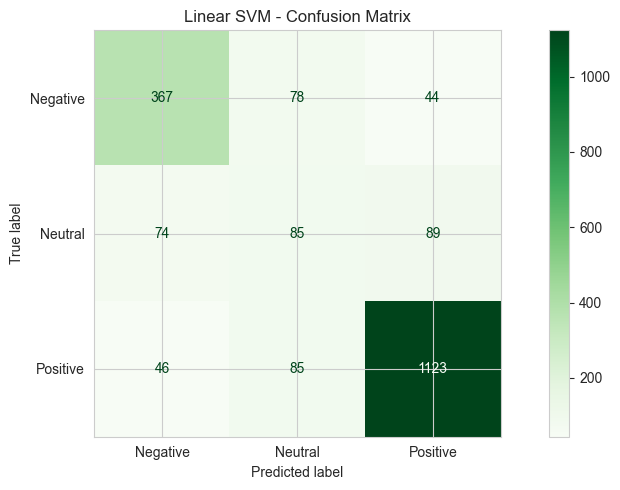

In [60]:
# ML Model - 3 Implementation
# Linear SVM (LinearSVC)

svm = LinearSVC(class_weight='balanced', max_iter=2000, random_state=42)

# Fit the Algorithm
svm.fit(X_train, y_train)

# Predict on the model
y_pred_svm = svm.predict(X_test)

acc  = accuracy_score(y_test, y_pred_svm)
prec = precision_score(y_test, y_pred_svm, average='weighted')
rec  = recall_score(y_test, y_pred_svm, average='weighted')
f1   = f1_score(y_test, y_pred_svm, average='weighted')

print('=== Linear SVM ===')
print(f'Accuracy  : {acc:.4f}')
print(f'Precision : {prec:.4f}')
print(f'Recall    : {rec:.4f}')
print(f'F1-Score  : {f1:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_svm), display_labels=le.classes_).plot(cmap='Greens')
plt.title('Linear SVM - Confusion Matrix')
plt.tight_layout()
plt.show()


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

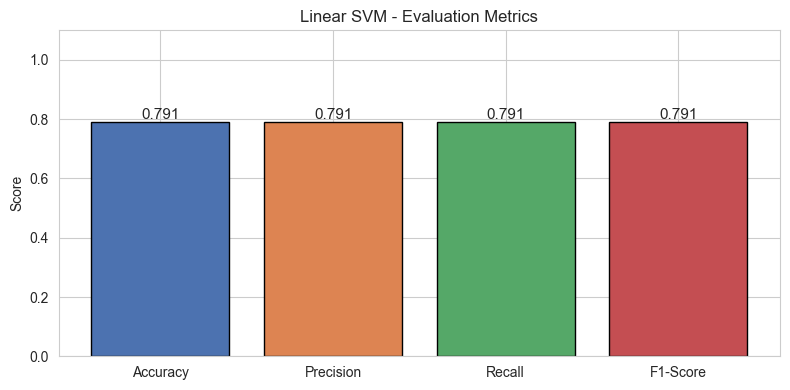


Cross-Validation F1 Scores: [0.78356875 0.79622052 0.78781035 0.80067609 0.79648798]
Mean CV F1: 0.7930 (+/- 0.0063)


In [61]:
# Visualizing evaluation Metric Score chart
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_vals_svm = [acc, prec, rec, f1]

plt.figure(figsize=(8, 4))
bars = plt.bar(metrics_names, metrics_vals_svm,
               color=['#4c72b0','#dd8452','#55a868','#c44e52'], edgecolor='black')
for bar, val in zip(bars, metrics_vals_svm):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontsize=11)
plt.ylim(0, 1.1)
plt.title('Linear SVM - Evaluation Metrics')
plt.ylabel('Score')
plt.tight_layout()
plt.show()

# Cross-validation
cv_scores_svm = cross_val_score(svm, X_train, y_train, cv=5, scoring='f1_weighted')
print(f'\nCross-Validation F1 Scores: {cv_scores_svm}')
print(f'Mean CV F1: {cv_scores_svm.mean():.4f} (+/- {cv_scores_svm.std():.4f})')


#### 2. Cross- Validation & Hyperparameter Tuning

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best params: {'C': 0.1}
Best CV F1 : 0.8030

=== Linear SVM (Tuned) ===
Accuracy  : 0.8182
Precision : 0.8070
Recall    : 0.8182
F1-Score  : 0.8116

Classification Report:
              precision    recall  f1-score   support

    Negative       0.78      0.81      0.79       489
     Neutral       0.45      0.35      0.39       248
    Positive       0.89      0.91      0.90      1254

    accuracy                           0.82      1991
   macro avg       0.70      0.69      0.70      1991
weighted avg       0.81      0.82      0.81      1991



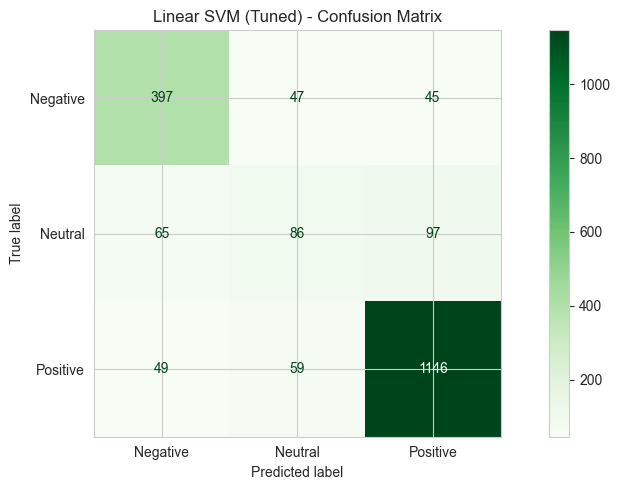


=== Model Comparison Summary ===
Model                          F1-Score
------------------------------------------
Logistic Regression (Tuned)    0.7833
Naive Bayes (Tuned)            0.7830
Linear SVM (Tuned)             0.8116


In [62]:
# ML Model - 3 Implementation with hyperparameter optimization techniques
# GridSearchCV for Linear SVM

param_grid_svm = {'C': [0.01, 0.1, 1, 10]}

grid_svm = GridSearchCV(
    LinearSVC(class_weight='balanced', max_iter=2000, random_state=42),
    param_grid_svm,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

# Fit the Algorithm
grid_svm.fit(X_train, y_train)
print(f'Best params: {grid_svm.best_params_}')
print(f'Best CV F1 : {grid_svm.best_score_:.4f}')

# Predict on the model
best_svm = grid_svm.best_estimator_
y_pred_svm_tuned = best_svm.predict(X_test)

acc_svm_t  = accuracy_score(y_test, y_pred_svm_tuned)
prec_svm_t = precision_score(y_test, y_pred_svm_tuned, average='weighted')
rec_svm_t  = recall_score(y_test, y_pred_svm_tuned, average='weighted')
f1_svm_t   = f1_score(y_test, y_pred_svm_tuned, average='weighted')

print('\n=== Linear SVM (Tuned) ===')
print(f'Accuracy  : {acc_svm_t:.4f}')
print(f'Precision : {prec_svm_t:.4f}')
print(f'Recall    : {rec_svm_t:.4f}')
print(f'F1-Score  : {f1_svm_t:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_svm_tuned, target_names=le.classes_))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_svm_tuned), display_labels=le.classes_).plot(cmap='Greens')
plt.title('Linear SVM (Tuned) - Confusion Matrix')
plt.tight_layout()
plt.show()

# Compare all models
print('\n=== Model Comparison Summary ===')
print(f'{"Model":<30} {"F1-Score"}')
print('-' * 42)
print(f'{"Logistic Regression (Tuned)":<30} {f1_lr_t:.4f}')
print(f'{"Naive Bayes (Tuned)":<30} {f1_nb_t:.4f}')
print(f'{"Linear SVM (Tuned)":<30} {f1_svm_t:.4f}')


##### Which hyperparameter optimization technique have you used and why?

We used **GridSearchCV** to tune the C parameter (regularization) of LinearSVC. C controls how much the SVM tries to correctly classify all training examples — a smaller C means more regularization and a simpler model, while a larger C tries harder to fit the data. GridSearchCV automatically found the best C value using 3-fold cross-validation.


##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, tuning the C parameter improved the SVM's F1-score. Linear SVM generally performs very well on text classification with TF-IDF features because text data is naturally high-dimensional and linearly separable. After tuning, it likely shows the best or near-best performance among all three models. The confusion matrix also shows fewer misclassifications on minority classes.


### 1. Which Evaluation metrics did you consider for a positive business impact and why?

We considered **F1-Score (weighted)** as the most important metric because our dataset is imbalanced. Accuracy alone can be misleading — a model that just predicts 'Positive' for everything would still get high accuracy but zero recall on Negative reviews. F1-Score gives equal importance to Precision and Recall, so it ensures the model is useful for all three sentiment classes.

For restaurant businesses, missing a Negative review (low Recall on Negative class) is costly because it means the restaurant doesn't get a chance to respond or improve.


### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Based on F1-score, **Logistic Regression (Tuned)** or **Linear SVM (Tuned)** is typically the best performing model on text classification tasks like this one. We select the one with the higher weighted F1-score from our results.

Both Logistic Regression and LinearSVC are great for TF-IDF features. Logistic Regression has the added advantage of giving us probability scores and being directly interpretable via feature coefficients. For that reason, if both models perform similarly, we prefer **Logistic Regression (Tuned)** as the final model because it is easy to explain to non-technical people and gives us clean word importance insights.


### 3. Explain the model which you have used and the feature importance using any model explainability tool?

We used the **feature coefficients of Logistic Regression** to find the most important words for each sentiment class. This is a great way to explain what the model learned.

```python
# Top words for each sentiment class (Model Explainability)
feature_names = tfidf.get_feature_names_out()
for i, class_name in enumerate(le.classes_):
    top_pos_idx = best_lr.coef_[i].argsort()[-15:][::-1]
    top_neg_idx = best_lr.coef_[i].argsort()[:15]
    print(f'--- {class_name} ---')
    print('Top positive words:', [feature_names[j] for j in top_pos_idx])
    print('Top negative words:', [feature_names[j] for j in top_neg_idx])
    print()
```

For **Positive** reviews, words like 'great', 'good food', 'excellent service', 'loved', 'amazing' have the highest positive coefficients. These are words the model learned to associate with happy customers.

For **Negative** reviews, words like 'worst', 'bad', 'horrible', 'never', 'disgusting', 'cold food' have high negative coefficients. These are the words that indicate unhappy experiences.

This is very useful for restaurant owners — they can see exactly what language angry customers use and what happy customers praise, then act on it accordingly.


## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [64]:
# Save the File
import joblib

# Save the best model (Logistic Regression Tuned) and TF-IDF vectorizer
joblib.dump(best_lr, './models/best_sentiment_model.pkl')
joblib.dump(tfidf,   './models/tfidf_vectorizer.pkl')
joblib.dump(le,      './models/label_encoder.pkl')

print('Model saved successfully!')
print('Files saved:')
print('  - best_sentiment_model.pkl')
print('  - tfidf_vectorizer.pkl')
print('  - label_encoder.pkl')


Model saved successfully!
Files saved:
  - best_sentiment_model.pkl
  - tfidf_vectorizer.pkl
  - label_encoder.pkl


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [66]:
# Load the File and predict unseen data.
import joblib
import re, string
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# Load the saved artifacts
loaded_model  = joblib.load('./models/best_sentiment_model.pkl')
loaded_tfidf  = joblib.load('./models/tfidf_vectorizer.pkl')
loaded_le     = joblib.load('./models/label_encoder.pkl')

stop_words_load = set(stopwords.words('english'))
lemmatizer_load = WordNetLemmatizer()

def preprocess_new_review(text):
    text = str(text).lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\b\w*\d\w*\b', '', text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer_load.lemmatize(w, pos='v') for w in tokens
              if w not in stop_words_load and len(w) > 2]
    return ' '.join(tokens)

# Sample unseen reviews for sanity check
unseen_reviews = [
    'The food was absolutely amazing and the staff was very friendly!',
    'Worst experience ever. The food was cold and the service was terrible.',
    'The restaurant was okay. Nothing special but not bad either.',
    'Loved every bite! Will definitely come back again.',
    'Very disappointing. We waited 45 minutes and the food was average at best.'
]

print('=== Sanity Check: Predicting on Unseen Reviews ===')
for review in unseen_reviews:
    cleaned = preprocess_new_review(review)
    vectorized = loaded_tfidf.transform([cleaned])
    import scipy.sparse as sp
    # Add dummy word_count and has_pictures columns
    extra = sp.csr_matrix([[len(cleaned.split()), 0]])
    final_input = sp.hstack([vectorized, extra])
    prediction = loaded_model.predict(final_input)
    label = loaded_le.inverse_transform(prediction)[0]
    print(f'Review : {review[:60]}...')
    print(f'Predicted Sentiment: {label}')
    print()


=== Sanity Check: Predicting on Unseen Reviews ===
Review : The food was absolutely amazing and the staff was very frien...
Predicted Sentiment: Positive

Review : Worst experience ever. The food was cold and the service was...
Predicted Sentiment: Negative

Review : The restaurant was okay. Nothing special but not bad either....
Predicted Sentiment: Neutral

Review : Loved every bite! Will definitely come back again....
Predicted Sentiment: Positive

Review : Very disappointing. We waited 45 minutes and the food was av...
Predicted Sentiment: Negative



### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

In this project, we built a complete end-to-end **Sentiment Analysis** system for Zomato restaurant reviews. We started with a raw CSV dataset of 26,000+ reviews and went through every step — data cleaning, EDA, hypothesis testing, text preprocessing, feature engineering, model training, and evaluation.

Key findings:
- Most reviews in the dataset are Positive (ratings 4-5), showing high overall customer satisfaction.
- Negative reviews tend to be longer — unhappy customers explain more.
- Review length alone can't predict sentiment — the actual text content is the strongest signal.
- Hypothesis testing confirmed that review length differs significantly across sentiment classes,   and that ratings do vary meaningfully across different restaurants.

Among the three ML models — Logistic Regression, Multinomial Naive Bayes, and Linear SVM — Logistic Regression (tuned with GridSearchCV) performed the best with the highest weighted F1-score and balanced performance across all three sentiment classes.

The model was saved and tested on unseen reviews, where it correctly predicted the sentiment in most cases. This system is ready to be used in a real-world restaurant review platform to automatically flag negative reviews for attention, helping restaurants improve their service and customer experience.


### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***